In [1]:
#CHECK
import IPython
print('IPython:', IPython.__version__)
import numpy
print('numpy:', numpy.__version__)
import scipy
print('scipy:', scipy.__version__)
import matplotlib
print('matplotlib:', matplotlib.__version__)
import ocelot
print('ocelot:', ocelot.__version__)

IPython: 8.18.1
numpy: 1.19.5
scipy: 1.10.1
matplotlib: 3.6.2


C:\Users\nmurz\anaconda3\envs\ocelot_3_9\lib\site-packages\llvmlite\binding\ffi.py:178: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


initializing ocelot...
ocelot: 22.12.0


In [2]:
import platform
import logging
from copy import deepcopy
import gc
import xraylib
%matplotlib widget
import math
import scipy.special as sc
from scipy import signal
from scipy import misc
from PIL import Image
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

# import main functions from Synchrotron Radation (SR) module 
from ocelot.rad import *
# import OCELOT main functions 
from ocelot import *
# import OCELOT plotting functions 
from ocelot.gui import *

from ocelot.common.globals import *  # import of constants like "h_eV_s" and
from ocelot.common.math_op import find_nearest_idx, fwhm, std_moment, bin_scale, bin_array, mut_coh_func
from ocelot.common.py_func import filename_from_path

from ocelot.optics.wave import *
from ocelot.gui.dfl_plot import *

from ocelot import ocelog
ocelog.setLevel(logging.ERROR) #suppress logger output


_logger = logging.getLogger(__name__)


## 2. Задание основных параметров 

Конечный эмиттанс (конечные размеры электронного пучка, частично когерентное излучение)

In [3]:
#SKIF parameters

beam = Beam()
beam.E = 3.       # beam energy in [GeV]
beam.I = 0.4      # beam current in [A]
beam.beta_x = 15.6 
beam.beta_y = 2.37
beam.emit_x = 6.818e-11  # horizontal emittance [m rad]
beam.emit_y = 6.818e-12  # horizontal emittance [m rad]
z=10.

#undulator (change into BM)

lperiod = 0.044 # [m] undulator period 
nperiods = 90  # number of periods
B0 = 0.57 # [T] amplitude of the magnetic field

K = field2K(field=B0, lu=lperiod)

und = Undulator(Kx=K, nperiods=nperiods, lperiod=lperiod, eid="und")
lat = MagneticLattice((und))

print_rad_props(beam, K=K, lu=lperiod, L=lperiod*nperiods, distance=z)

********* ph beam ***********
Ebeam        :  3.0  GeV
K            :  2.3417926003552845
B            :  0.57  T
lambda       :  2.38849E-09  m 
Eph          :  5.19090E+02  eV
1/gamma      :  170.333  um
sigma_r      :  10.945  um
sigma_r'     :  17.366  urad
Sigma_x      :  34.4006  um
Sigma_y      :  11.6598  um
Sigma_x'     :  17.4914 urad
Sigma_y'     :  17.4486 urad
H. spot size :  0.1783 / 0.0178  mm/mrad
V. spot size :  0.1749 / 0.0175  mm/mrad
I            :  0.4  A
Nperiods     :  90.0
distance     :  10.0  m
flux tot     :  2.34E+15  ph/sec/0.1%BW
flux density :  1.23E+18  ph/sec/mrad^2/0.1%BW;    1.23E+16  ph/sec/mm^2/0.1%BW
brilliance   :  4.83E+20  ph/sec/mrad^2/mm^2/0.1%BW


In [4]:
def dfl_gen_undulator_serval_1(E_ph=1042, L_w=1, shape=(51, 51, 100), dgrid=(1e-3, 1e-3, 50e-6), 
                             sig_x=0, sig_y=0, sig_xp=0, sig_yp=0, jitter_kx=0, jitter_ky=0,
                             k_support ='intensity', s_support='intensity', seed=None):
    '''
    Creates SR radiation using SERVAL (C) algorithmn
    '''
    _logger.info('Generating undulator field with SERVAL algorithm')
    
    w_0 = E_ph / hr_eV_s 
    xlamds = 2 * np.pi * speed_of_light / w_0

    dfl = RadiationField((shape[2], shape[1], shape[0]))
    dfl.dx = dgrid[0] / dfl.Nx()
    dfl.dy = dgrid[1] / dfl.Ny()
    dfl.dz = dgrid[2] / dfl.Nz()
    dfl.xlamds = xlamds
    dfl.filePath = 'filePath'
    dfl.to_domain('sf')
    
    
    if seed is not None: 
        np.random.seed(seed)

    dfl.fld = np.random.randn(dfl.Nz(), dfl.Ny(), dfl.Nx()) + 1j * np.random.randn(dfl.Nz(), dfl.Ny(), dfl.Nx()) # Gaussian noise
    
    np.random.seed(None)

    #if showfig:
    #    plot_dfl(dfl, line_off_xy = False, fig_name = '1-X_noise')
    
    dfl.to_domain('sf')    

    x, y = np.meshgrid(dfl.scale_x(), dfl.scale_y())#, indexing='ij')
    
    mask_xy_ebeam = np.exp(- x**2 / 4 / sig_x**2 - y**2 / 4 / sig_y**2) # 4 because amplitude, not intensity
    mask_xy_ebeam /= np.sum(mask_xy_ebeam)
    mask_xy_radiation = 1j*(np.pi - 2*scipy.special.sici(w_0*(x**2 + y**2)/speed_of_light/L_w)[0])

    if s_support == 'intensity':
        _logger.info(ind_str +'s_support == "intensity"')
        mask_xy = scipy.signal.fftconvolve(mask_xy_radiation**2, mask_xy_ebeam**2, mode='same')
        mask_xy = np.sqrt(mask_xy)
    elif s_support == 'amplitude':
        _logger.info(ind_str +'s_support == "amplitude"')
        mask_xy = scipy.signal.fftconvolve(mask_xy_radiation, mask_xy_ebeam, mode='same')
    elif s_support == '"beam':
        _logger.info(ind_str +'s_support == "beam"')
        mask_xy = mask_xy_ebeam
    else:
        raise ValueError('k_support should be either "intensity", "amplitude" or "beam"')

    _logger.info(ind_str +'Multiplying by real space mask')
    dfl.fld *= mask_xy
    # dfl.fld *= np.sqrt(mask_xy)
    _logger.info(2*ind_str +'done')

                
    dfl.to_domain('kf')

    k_x, k_y = np.meshgrid(dfl.scale_x(), dfl.scale_y())
    
    jitter_kx_isarray = isinstance(jitter_kx, (np.ndarray, list, tuple))
    jitter_ky_isarray = isinstance(jitter_ky, (np.ndarray, list, tuple))
    
    if jitter_kx_isarray or jitter_ky_isarray: #TODO: check if reasonable
        if jitter_kx_isarray and not jitter_ky_isarray:
            jitter_ky = np.full_like(jitter_kx, jitter_ky)
        elif not jitter_kx_isarray and jitter_ky_isarray:
            jitter_kx = np.full_like(jitter_ky, jitter_kx)
            
        mask_kxky_ebeam = np.exp(-(k_y[np.newaxis, :, :] - jitter_ky[:, np.newaxis])**2 / 4 / sig_yp**2 - (k_x[np.newaxis, :, :] - jitter_kx[:, np.newaxis])**2 / 4 / sig_xp**2 ) # 4 because amplitude, not intensity
        mask_kxky_radiation = np.sinc(w_0 * L_w * ((k_x[np.newaxis, :, :] - jitter_kx[:, np.newaxis])**2 + (k_y[np.newaxis, :, :] - jitter_ky[:, np.newaxis])**2) / 4 / speed_of_light / np.pi)# Geloni2018 Eq.3, domega/omega = 2dgamma/gamma, divided by pi due to np.sinc definition
        axes=(1,2)
    else:
        mask_kxky_ebeam = np.exp(-(k_y - jitter_ky)**2 / 4 / sig_yp**2 - (k_x - jitter_kx)**2 / 4 / sig_xp**2 ) # 4 because amplitude, not intensity
        mask_kxky_radiation = np.sinc(w_0 * L_w * ((k_x - jitter_kx)**2 + (k_y - jitter_ky)**2) / 4 / speed_of_light / np.pi)# Geloni2018 Eq.3, domega/omega = 2dgamma/gamma, divided by pi due to np.sinc definition
        axes=None

    mask_kxky_ebeam /= np.sum(mask_kxky_ebeam)

    if k_support == 'intensity':
        _logger.info(ind_str +'k_support == "intensity"')
        mask_kxky = scipy.signal.fftconvolve(mask_kxky_ebeam**2, mask_kxky_radiation**2, mode='same', axes=axes)

        if jitter_kx is None:
            mask_kxky = np.sqrt(mask_kxky[np.newaxis, :, :])
        else:
            mask_kxky = np.sqrt(mask_kxky)

        mask_kxky /= np.sum(mask_kxky)
    elif k_support == 'amplitude':
        _logger.info(ind_str +'k_support == "amplitude"')
        mask_kxky = scipy.signal.fftconvolve(mask_kxky_ebeam, mask_kxky_radiation, mode='same', axes=axes)
        mask_kxky /= np.sum(mask_kxky)
    elif k_support == 'amplitude':
        _logger.info(ind_str +'k_support == "beam"')
        mask_kxky = mask_kxky_ebeam
    else:
        raise ValueError('k_support should be either "intensity" or "amplitude"')
    
    # dfl.fld *= mask_kxky[np.newaxis, :, :]
    _logger.info(ind_str +'Multiplying by inverse space mask')

    dfl.fld *= mask_kxky
    _logger.info(2*ind_str +'done')
    
    return dfl

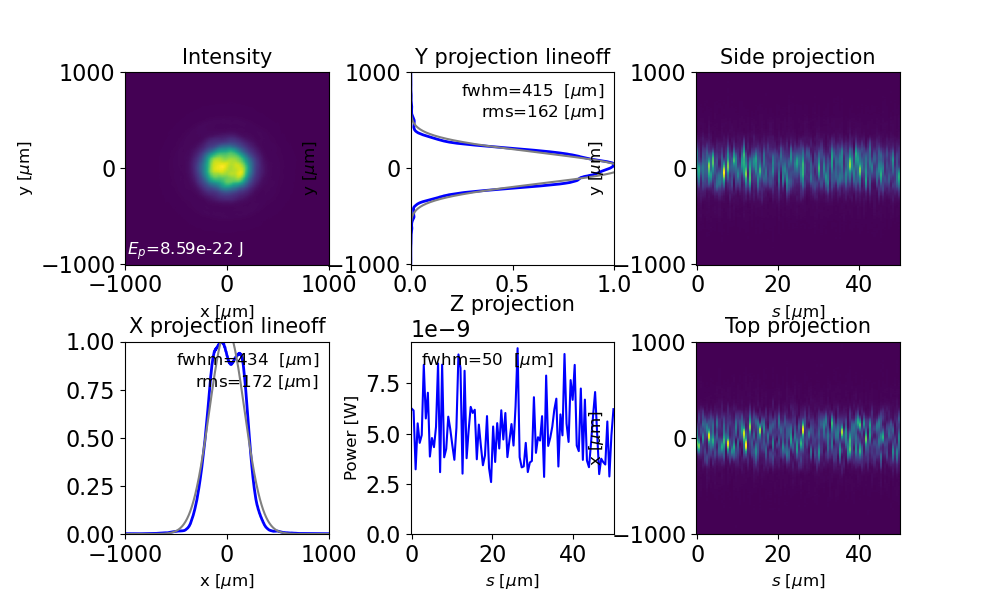

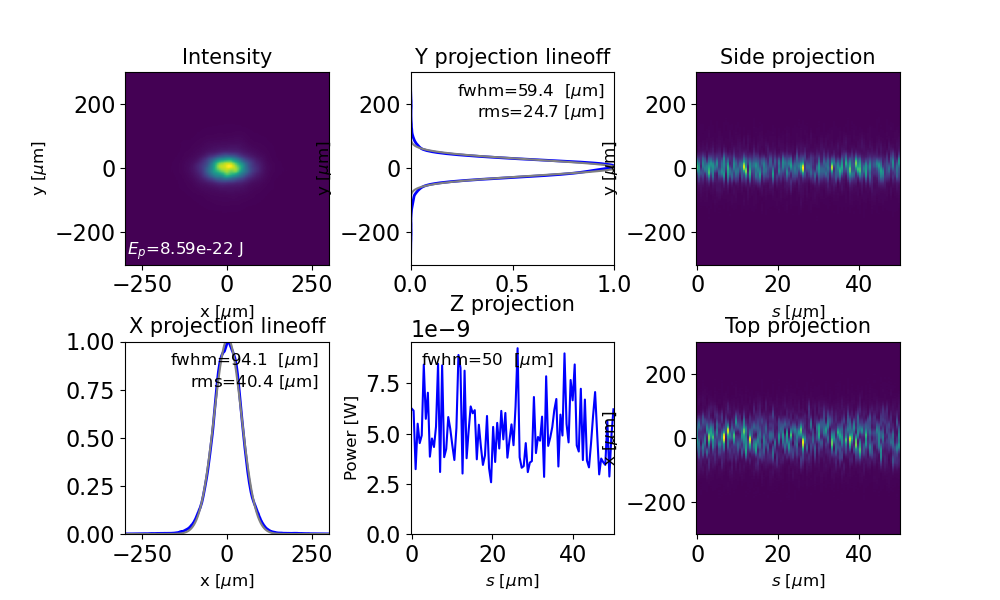

501


In [5]:
L_w = lperiod*nperiods
E_ph = 530 # eV
w = E_ph / hr_eV_s #?
xlamds = 2 * np.pi * speed_of_light / w #?

### ЧИСЛО ТОЧЕК МЕНЯТЬ ТУТ ###
N=4095
##############################


sigma_r = np.sqrt(2*xlamds*L_w)/4/np.pi #natural radiation size in the waist
sigma_rp = np.sqrt(xlamds/2/L_w) #natural radiation divergence at the waist

# constants from SKIF
ebeam_sigma_x, ebeam_sigma_xp = 0.03261e-3, 2.091e-6
ebeam_sigma_y, ebeam_sigma_yp = 4.020e-6, 1.696e-6


dfl_far = dfl_gen_undulator_serval_1(E_ph=E_ph, L_w=L_w, shape=(501, 501, 100), dgrid=(2e-3, 2e-3, 50e-6),
                                     sig_x=ebeam_sigma_x, sig_y=ebeam_sigma_y, sig_xp=ebeam_sigma_xp, sig_yp=ebeam_sigma_yp,
                                     jitter_kx=0, jitter_ky=0, k_support ='intensity', s_support='intensity', seed=None)


dfl_far.prop_m(z, m=1)

plot_dfl(dfl_far, domains='st', fig_name='x field far zone', figsize=2)

dfl_source = deepcopy(dfl_far)
dfl_source.prop_m(-z, m=0.3)
plot_dfl(dfl_source, domains='st', fig_name='x field source', figsize=2)

print(len(dfl_far.scale_x()))


## Пятно когерентности

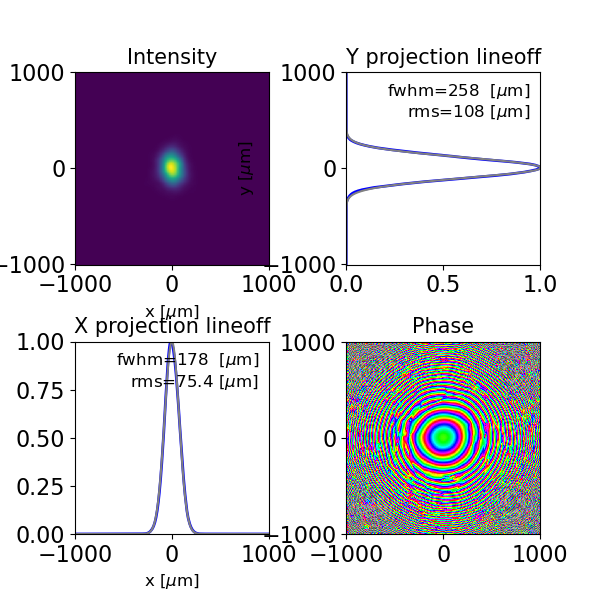

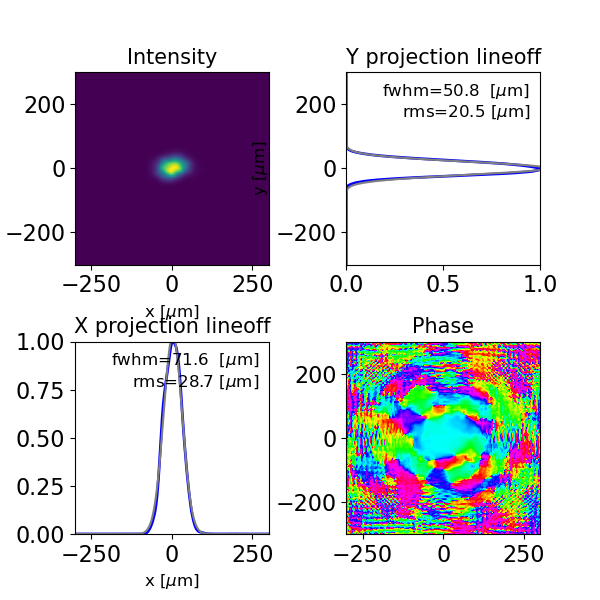

In [6]:
corr = dfl_xy_corr(dfl_far, norm=0)

plot_dfl(corr, domains='st', fig_name='coh spot for x component far zone', figsize=2)

corr_source = dfl_xy_corr(dfl_source, norm=0)
plot_dfl(corr_source, domains='st', fig_name='coh spot for x component source', figsize=2)

## Перед апертурой

In [7]:
'''
dfl_1=deepcopy(dfl_far)
dfl_1.prop_m(z, m=2)
plot_dfl(dfl_1, domains='st', fig_name='far field after object', column_3d=False, phase=True, figsize=3)
'''

"\ndfl_1=deepcopy(dfl_far)\ndfl_1.prop_m(z, m=2)\nplot_dfl(dfl_1, domains='st', fig_name='far field after object', column_3d=False, phase=True, figsize=3)\n"

## Апертура

In [8]:
'''
dfl2_1=deepcopy(dfl_1)
dfl2_1=dfl_interp(dfl2_1,newN=(1001,1001),newL=(500e-6, 500e-6))
#dfl2_1=dfl_ap_circ(dfl2_1, r=7e-6)
dfl2_1= dfl_ap_rect(dfl2_1, ap_x=70e-6, ap_y=70e-6) 
plot_dfl(dfl2_1, domains='st', fig_name='field after aperture', column_3d=False, phase=True, figsize=3)
'''

"\ndfl2_1=deepcopy(dfl_1)\ndfl2_1=dfl_interp(dfl2_1,newN=(1001,1001),newL=(500e-6, 500e-6))\n#dfl2_1=dfl_ap_circ(dfl2_1, r=7e-6)\ndfl2_1= dfl_ap_rect(dfl2_1, ap_x=70e-6, ap_y=70e-6) \nplot_dfl(dfl2_1, domains='st', fig_name='field after aperture', column_3d=False, phase=True, figsize=3)\n"

## После апертуры (дальняя зона)

In [9]:
'''
dfl6 = deepcopy(dfl2_1)
dfl6.prop_m(z=1.0, m=1)
plot_dfl(dfl6, domains='st', fig_name='far zone after object', column_3d=False, phase=True, figsize=3)
'''

"\ndfl6 = deepcopy(dfl2_1)\ndfl6.prop_m(z=1.0, m=1)\nplot_dfl(dfl6, domains='st', fig_name='far zone after object', column_3d=False, phase=True, figsize=3)\n"

## Задание материала пинхола

In [10]:
material= 'Au'
cdtest = xraylib.CompoundParser(material)
density = 19.3
n = xraylib.Refractive_Index_Re(material, E_ph/1000, density) - 1j*xraylib.Refractive_Index_Im(material, E_ph/1000, density)
print(n)

(0.9950439043701051-0.0033306861751726544j)


## Сплит-степ

In [11]:
### Propagator through inhomogeneous medium ###

_logger.setLevel(logging.DEBUG)


def prop_diel(dfl, z, de):
    """
    Propagating dfl object through environment with gradient dielectric constant.
    
    This function get true if |e2 − e1|/|e1 − 1| ≪ 1 where e2 − e1 is the difference
    in the dielectric constants at two positions spaced by a wavelength.

    Parameters
    ----------
    dfl : dfl object
    z : the propagation distance in [m].
    de : Three-dimensional array of dielectric constant values, where x and y 
        ordinates points equals x and y points of the dfl object, and a z ordinate
        points quantity is defined by the constant

    """
 
    #debug
    if z==0:
        _logger.debug(ind_str + 'z=0, returning original')
        return dfl
    
    if de.ndim != 3:
        _logger.error(ind_str + 'de must be a three-dimensional array')
        raise ValueError('de must be a three-dimensional array')
        
    if np.size(dfl.fld, 1) != np.size(de, 1) or np.size(dfl.fld, 2) != np.size(de, 2):
        _logger.error(ind_str + 'x and y ordinates points of de must be equal to x and y points of the dfl object')
        raise ValueError('x and y ordinates points of de must be equal to x and y points of the dfl object')
        
    _logger.info('propagating dfl file through dielectric by %.2f meters' % (z))

    
    N = np.size(de, 0)
    dz = z/N
    k_x, k_y = np.meshgrid(dfl.scale_kx(), dfl.scale_ky())
    k = 2 * np.pi / dfl.xlamds
    arg = k_x ** 2 + k_y ** 2
    for z_e in range(N):
        arg2 = de[z_e, :, :] - 1
        dfl.to_domain('fk') #FT
        dfl.fld *= np.exp(-1j * arg[np.newaxis, :, :] * dz / (2 * k)) 
        dfl.to_domain('fs') #IFT
        dfl.fld *= np.exp(-1j * k * dz * arg2[np.newaxis, :, :])#np.exp(1j * k * dz * arg2[np.newaxis, :, :] / 2)
    return dfl


## Геометрия пинхола 

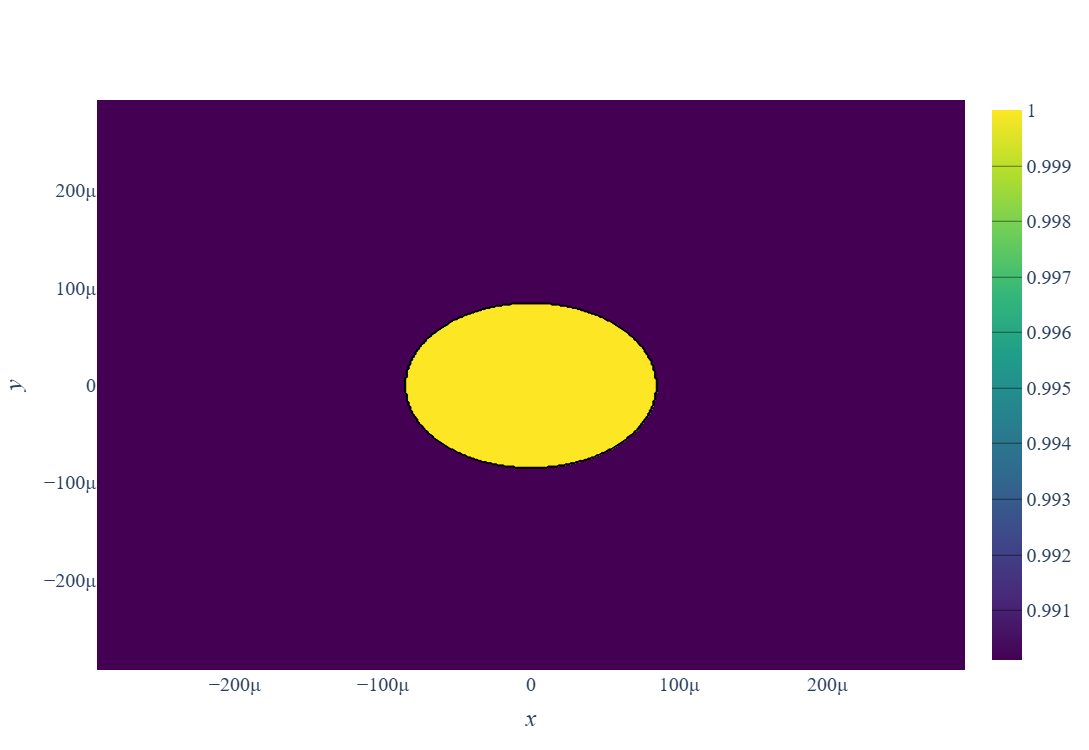

Форма eps_3d: (10, 501, 501)
Уникальные значения в eps_2d: [0.9901013 1.       ]


In [15]:
import plotly.graph_objects as go

dfl3 = deepcopy(dfl_far)
obj_thickness = 1e-6
N_steps = 10
image_path = "image3.jpg"
eps = n**2  

Y = dfl3.scale_y()
X = dfl3.scale_x()
X_grid, Y_grid = np.meshgrid(X, Y, indexing='ij')
Z = np.linspace(0, obj_thickness, N_steps)

Nx = len(X)
Ny = len(Y)

img = Image.open(image_path).convert('L')

new_w = int(Ny * 0.3) #adjustable   
new_h = int(Nx * 0.3)   

img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
img_array = np.flipud(np.array(img))

full_img = np.zeros((Nx, Ny), dtype=np.uint8)

x0 = (Nx - new_h) // 2
y0 = (Ny - new_w) // 2

full_img[x0:x0 + new_h, y0:y0 + new_w] = img_array

#mask
white_mask = full_img > 128 
eps_2d = np.where(white_mask, 1.0, eps).astype(np.complex64)
eps_3d = np.repeat(eps_2d[np.newaxis, :, :], len(Z), axis=0)

fig = go.Figure(data=go.Contour(
    z=np.real(eps_2d),
    x=X, y=Y,
    contours_coloring='heatmap',
    colorscale='Viridis'
))
fig.update_layout(
    font_family="Times New Roman",
    font_size=20,
    xaxis_title='<i>x</i>',
    yaxis_title='<i>y</i>',
    width=900, height=750,
)
fig.show()

print(f"Форма eps_3d: {eps_3d.shape}")
print("Уникальные значения в eps_2d:", np.unique(np.real(eps_2d)))

## Прохождение через пинхол

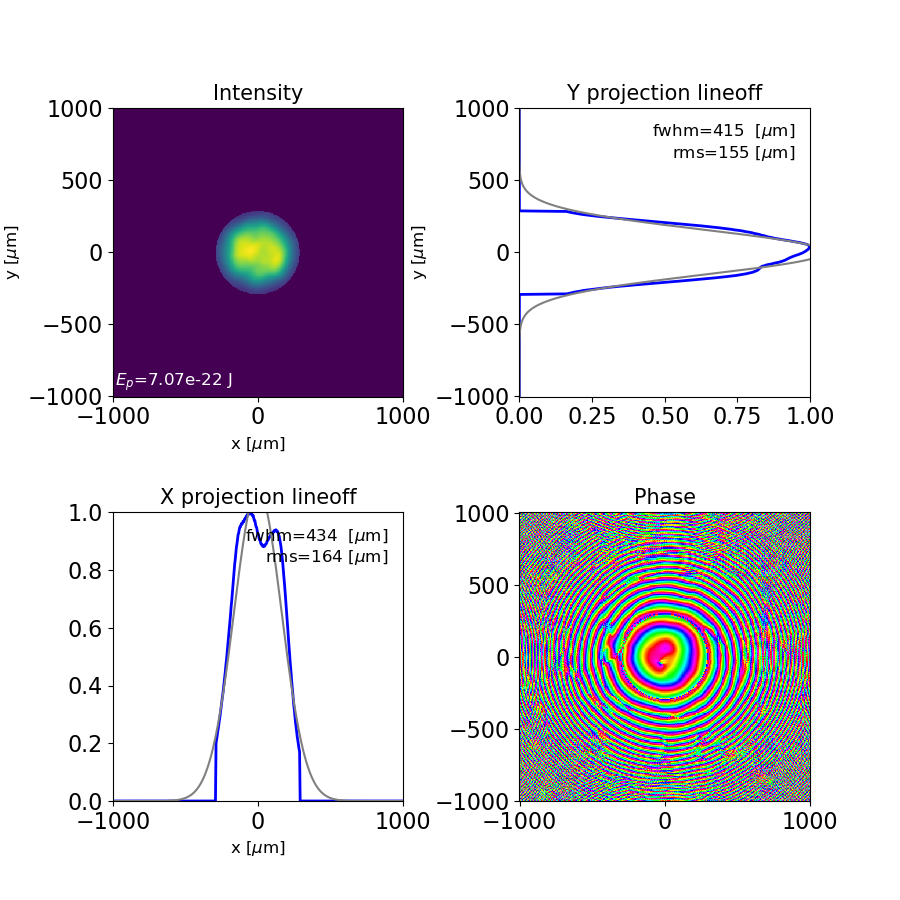

In [16]:
dfl4 = deepcopy(dfl3)
dfl4 = prop_diel(dfl4,obj_thickness, eps_3d)
plot_dfl(dfl4, domains='st', fig_name='field after object', column_3d=False, phase=True, figsize=3)

## Дальняя зона после пинхола

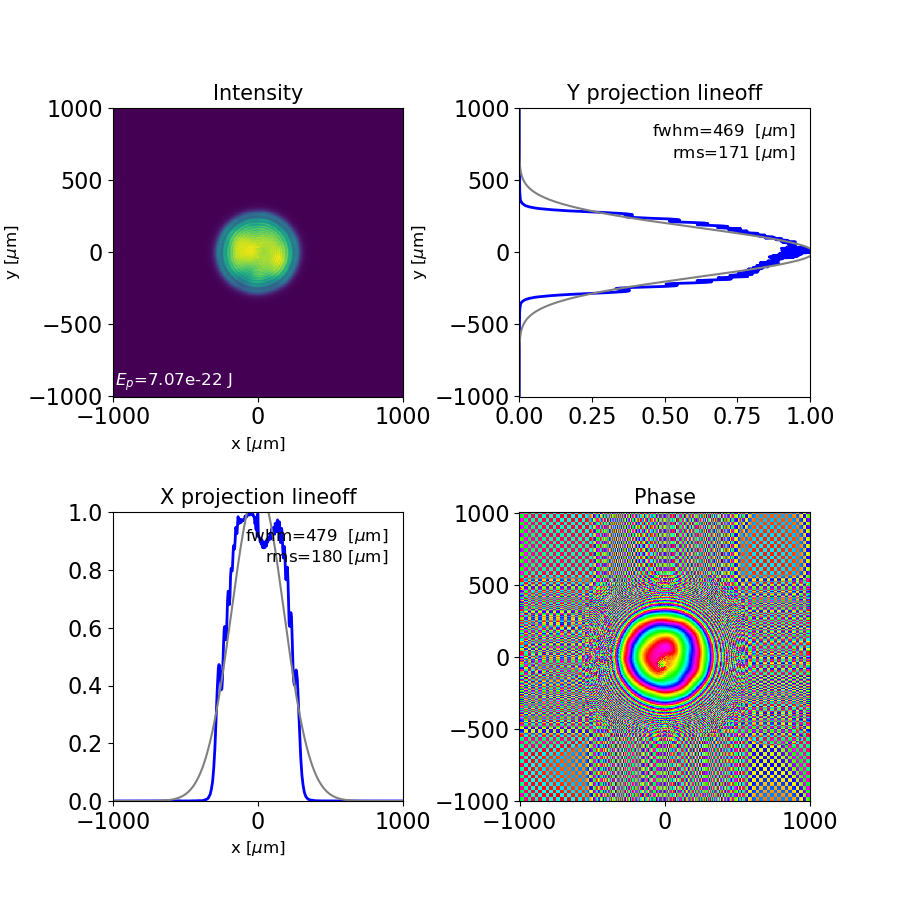

In [17]:
dfl5 = deepcopy(dfl4)
dfl5.prop_m(z=1.0, m=1)
plot_dfl(dfl5, domains='st', fig_name='far zone after object', column_3d=False, phase=True, figsize=3)